# Семантическая сегментация деталей трубопроводной арматуры по LiDAR `.ply`

In [3]:
!pip install numpy pandas matplotlib scikit-learn tqdm torch


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
import math
import time
import copy
import random
import zipfile
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.9.1+cu128
cuda available: False


In [5]:
# =========================
# 1. Конфигурация
# =========================

SEED = 52

DATA_DIR = Path("13")
DATA_ZIP = Path("13-20260621T195013Z-3-001.zip")

EXTRACT_DIR = Path("valve_dataset_extracted")
OUTPUT_DIR  = Path("outputs_valve_segmentation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 10
CLASS_NAMES = [f"class_{i}" for i in range(NUM_CLASSES)]

EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 10

MODELS_TO_TRAIN = ["pointnet", "dgcnn"] if torch.cuda.is_available() else ["pointnet"]

MODEL_SETTINGS = {
    "pointnet": {
        "n_points": 4096,
        "batch_size": 8 if torch.cuda.is_available() else 2,
    },
    "dgcnn": {
        "n_points": 2048,
        "batch_size": 4 if torch.cuda.is_available() else 1,
        "k": 20,
    },
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

print("DATA_ZIP:", DATA_ZIP)
print("EXTRACT_DIR:", EXTRACT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DEVICE:", DEVICE)
print("MODELS_TO_TRAIN:", MODELS_TO_TRAIN)

DATA_ZIP: 13-20260621T195013Z-3-001.zip
EXTRACT_DIR: valve_dataset_extracted
OUTPUT_DIR: outputs_valve_segmentation
DEVICE: cpu
MODELS_TO_TRAIN: ['pointnet']


## 2. Распаковка архива и поиск `.ply`

In [6]:
def find_ply_files_in_dir(data_dir: Path) -> List[Path]:
    data_dir = Path(data_dir)
    if not data_dir.exists():
        return []
    return sorted(data_dir.rglob("*.ply"))


def get_ply_files(data_dir: Path, zip_path: Path, extract_dir: Path) -> List[Path]:
    ply_files = find_ply_files_in_dir(data_dir)
    if len(ply_files) > 0:
        print(f"Найдены .ply в DATA_DIR: {data_dir}")
        return ply_files

    ply_files = find_ply_files_in_dir(extract_dir)
    if len(ply_files) > 0:
        print(f"Найдены .ply в EXTRACT_DIR: {extract_dir}")
        return ply_files

    if not zip_path.exists():
        raise FileNotFoundError(
            f"Не найдены ни папка с .ply ({data_dir}), ни архив ({zip_path}).\n"
            "Положи папку 13 рядом с ноутбуком или укажи путь в DATA_DIR."
        )

    extract_dir.mkdir(parents=True, exist_ok=True)
    print(f"Распаковываю архив {zip_path} -> {extract_dir}")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    ply_files = find_ply_files_in_dir(extract_dir)

    if len(ply_files) == 0:
        raise RuntimeError("После распаковки не найдено ни одного .ply файла.")

    return ply_files


ply_files = get_ply_files(DATA_DIR, DATA_ZIP, EXTRACT_DIR)

print("Количество .ply файлов:", len(ply_files))
print("Первые 5 файлов:")
for p in ply_files[:5]:
    print(" ", p)

Найдены .ply в DATA_DIR: 13
Количество .ply файлов: 500
Первые 5 файлов:
  13/valve_0001_lidar_classes.ply
  13/valve_0002_lidar_classes.ply
  13/valve_0003_lidar_classes.ply
  13/valve_0004_lidar_classes.ply
  13/valve_0005_lidar_classes.ply


## 3. Загрузчик ASCII `.ply`

In [25]:
def read_ply_ascii(path: Path) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """
    Читает ASCII PLY с полями x, y, z и scalar_Label.

    Returns
    -------
    coords : np.ndarray, shape [N, 3], dtype float32
    labels : np.ndarray, shape [N], dtype int64
    meta   : dict с информацией из заголовка
    """
    path = Path(path)

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        first = f.readline().strip()
        if first != "ply":
            raise ValueError(f"{path}: файл не начинается с 'ply'")

        vertex_count = None
        properties = []
        fmt = None

        while True:
            line = f.readline()
            if line == "":
                raise ValueError(f"{path}: заголовок PLY не завершен end_header")
            line = line.strip()

            if line.startswith("format"):
                fmt = line
                if "ascii" not in line:
                    raise ValueError(f"{path}: ожидается ASCII PLY, получено: {line}")

            elif line.startswith("element vertex"):
                vertex_count = int(line.split()[-1])

            elif line.startswith("property"):
                parts = line.split()
                if len(parts) >= 3 and parts[1] != "list":
                    properties.append(parts[-1])

            elif line == "end_header":
                break

        if vertex_count is None:
            raise ValueError(f"{path}: не найден element vertex N")

        data = np.loadtxt(f, dtype=np.float32, max_rows=vertex_count)

    if data.ndim == 1:
        data = data.reshape(1, -1)

    required = ["x", "y", "z", "scalar_Label"]
    missing = [name for name in required if name not in properties]
    if missing:
        raise ValueError(f"{path}: нет полей {missing}. Найдены поля: {properties}")

    idx_x = properties.index("x")
    idx_y = properties.index("y")
    idx_z = properties.index("z")
    idx_label = properties.index("scalar_Label")

    coords = data[:, [idx_x, idx_y, idx_z]].astype(np.float32)
    labels = data[:, idx_label].astype(np.int64)

    meta = {
        "path": str(path),
        "format": fmt,
        "vertex_count": int(vertex_count),
        "properties": properties,
    }
    return coords, labels, meta

coords, labels, meta = read_ply_ascii(ply_files[0])
print(meta)
print("coords:", coords.shape, coords.dtype)
print("labels:", labels.shape, labels.dtype)
print("unique labels:", np.unique(labels))

{'path': '13/valve_0001_lidar_classes.ply', 'format': 'format ascii 1.0', 'vertex_count': 7218, 'properties': ['x', 'y', 'z', 'scalar_Label']}
coords: (7218, 3) float32
labels: (7218,) int64
unique labels: [0 1 2 3 4 5 6 7 8 9]


## 4. EDA: структура файлов, число точек, баланс классов

In [8]:
def collect_dataset_stats(paths: List[Path], num_classes: int = NUM_CLASSES) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    total_counts = np.zeros(num_classes, dtype=np.int64)

    for path in tqdm(paths, desc="Сбор статистики"):
        coords, labels, meta = read_ply_ascii(path)
        uniq, counts = np.unique(labels, return_counts=True)

        row = {
            "file": path.name,
            "path": str(path),
            "n_points": len(labels),
            "min_label": int(labels.min()),
            "max_label": int(labels.max()),
            "n_unique_labels": int(len(uniq)),
        }

        for c in range(num_classes):
            cnt = int((labels == c).sum())
            row[f"class_{c}_count"] = cnt
            row[f"class_{c}_share"] = cnt / len(labels)
            total_counts[c] += cnt

        rows.append(row)

    files_df = pd.DataFrame(rows)

    class_df = pd.DataFrame({
        "class_id": np.arange(num_classes),
        "class_name": CLASS_NAMES,
        "count": total_counts,
        "share": total_counts / total_counts.sum(),
    })
    return files_df, class_df

files_df, class_df = collect_dataset_stats(ply_files)

display(files_df.head())
display(class_df)

files_df.to_csv(OUTPUT_DIR / "files_stats.csv", index=False)
class_df.to_csv(OUTPUT_DIR / "class_distribution.csv", index=False)

print("Всего точек:", int(class_df["count"].sum()))
print("min / median / max точек на объект:",
      int(files_df["n_points"].min()),
      int(files_df["n_points"].median()),
      int(files_df["n_points"].max()))
print("Уникальные наборы меток по файлам:", files_df["n_unique_labels"].value_counts().to_dict())

Сбор статистики:   0%|          | 0/500 [00:00<?, ?it/s]

,file,path,n_points,min_label,max_label,n_unique_labels,class_0_count,class_0_share,class_1_count,class_1_share,...,class_5_count,class_5_share,class_6_count,class_6_share,class_7_count,class_7_share,class_8_count,class_8_share,class_9_count,class_9_share
0,valve_0001_lidar_classes.ply,13/valve_0001_lidar_classes.ply,7218,0,9,10,1207,0.167221,1105,0.153089,...,65,0.009005,492,0.068163,798,0.110557,40,0.005542,2685,0.371987
1,valve_0002_lidar_classes.ply,13/valve_0002_lidar_classes.ply,7106,0,9,10,1063,0.149592,850,0.119617,...,91,0.012806,651,0.091613,446,0.062764,48,0.006755,2762,0.388686
2,valve_0003_lidar_classes.ply,13/valve_0003_lidar_classes.ply,7368,0,9,10,1058,0.143594,742,0.100706,...,82,0.011129,745,0.101113,634,0.086048,46,0.006243,2787,0.378257
3,valve_0004_lidar_classes.ply,13/valve_0004_lidar_classes.ply,7220,0,9,10,1255,0.173823,939,0.130055,...,98,0.013573,617,0.085457,502,0.069529,42,0.005817,2635,0.364958
4,valve_0005_lidar_classes.ply,13/valve_0005_lidar_classes.ply,8268,0,9,10,1478,0.178761,1055,0.127600,...,65,0.007862,775,0.093735,779,0.094219,52,0.006289,3103,0.375302


,class_id,class_name,count,share
0,0,class_0,643778,0.165336
1,1,class_1,454864,0.116819
2,2,class_2,233413,0.059946
3,3,class_3,311555,0.080014
4,4,class_4,32343,0.008306
5,5,class_5,46691,0.011991
6,6,class_6,352314,0.090482
7,7,class_7,340708,0.087501
8,8,class_8,23057,0.005922
9,9,class_9,1455021,0.373682


Всего точек: 3893744
min / median / max точек на объект: 6715 7741 9058
Уникальные наборы меток по файлам: {10: 500}


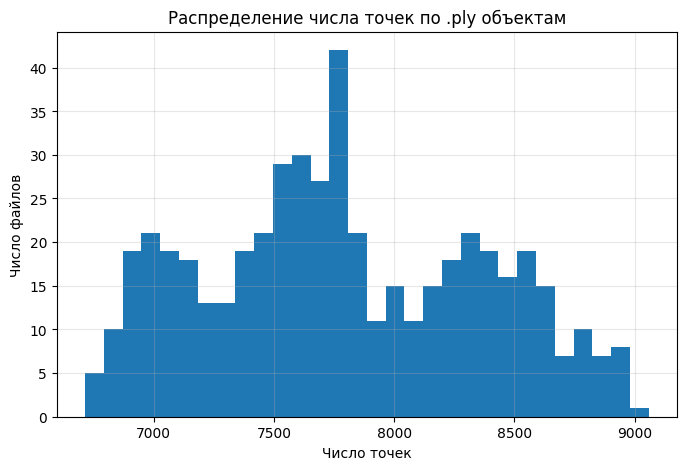

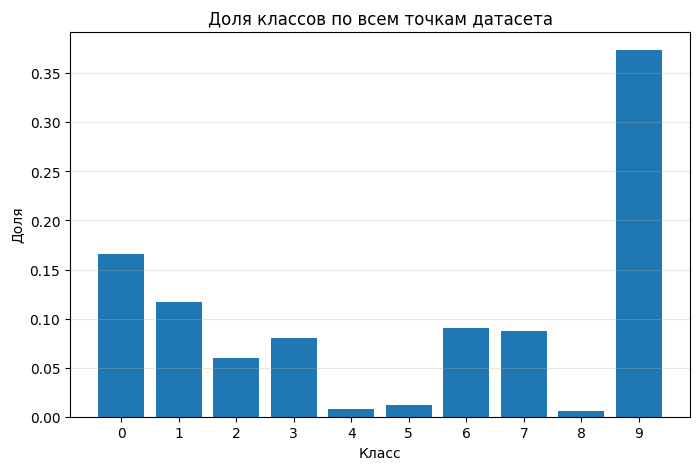

In [9]:
# Гистограмма числа точек на объект
plt.figure(figsize=(8, 5))
plt.hist(files_df["n_points"], bins=30)
plt.title("Распределение числа точек по .ply объектам")
plt.xlabel("Число точек")
plt.ylabel("Число файлов")
plt.grid(True, alpha=0.3)
plt.show()

# Распределение классов по всему датасету
plt.figure(figsize=(8, 5))
plt.bar(class_df["class_id"], class_df["share"])
plt.title("Доля классов по всем точкам датасета")
plt.xlabel("Класс")
plt.ylabel("Доля")
plt.xticks(class_df["class_id"])
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 5. Визуализация облаков точек

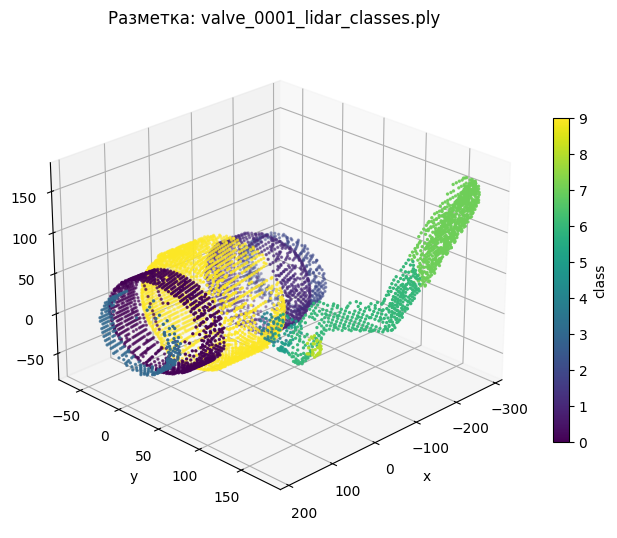

In [10]:
def visualize_cloud(coords: np.ndarray,
                    labels: Optional[np.ndarray] = None,
                    title: str = "Point cloud",
                    max_points: int = 6000,
                    elev: int = 25,
                    azim: int = 45):
    """Простая 3D-визуализация облака точек."""
    coords = np.asarray(coords)
    if labels is not None:
        labels = np.asarray(labels)

    if len(coords) > max_points:
        idx = np.random.choice(len(coords), max_points, replace=False)
        coords_plot = coords[idx]
        labels_plot = labels[idx] if labels is not None else None
    else:
        coords_plot = coords
        labels_plot = labels

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    if labels_plot is None:
        ax.scatter(coords_plot[:, 0], coords_plot[:, 1], coords_plot[:, 2], s=2)
    else:
        sc = ax.scatter(coords_plot[:, 0], coords_plot[:, 1], coords_plot[:, 2],
                        c=labels_plot, s=2)
        plt.colorbar(sc, ax=ax, shrink=0.6, label="class")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=elev, azim=azim)
    plt.show()

sample_path = ply_files[0]
coords, labels, _ = read_ply_ascii(sample_path)
visualize_cloud(coords, labels, title=f"Разметка: {sample_path.name}")

## 6. Обучение, тест, валидация по объектам

In [11]:
train_paths, temp_paths = train_test_split(
    ply_files,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
)

split_df = pd.DataFrame(
    [{"path": str(p), "file": p.name, "split": "train"} for p in train_paths] +
    [{"path": str(p), "file": p.name, "split": "val"} for p in val_paths] +
    [{"path": str(p), "file": p.name, "split": "test"} for p in test_paths]
)

display(split_df["split"].value_counts())
split_df.to_csv(OUTPUT_DIR / "train_val_test_split.csv", index=False)

print("train:", len(train_paths))
print("val:", len(val_paths))
print("test:", len(test_paths))

split
train    350
val       75
test      75
Name: count, dtype: int64

train: 350
val: 75
test: 75


## 7. Нормализация,  сэмплинг и аугментации

In [12]:
def normalize_coords(coords: np.ndarray) -> np.ndarray:
    """
    Центрирование и масштабирование облака в единичную сферу.
    """
    coords = coords.astype(np.float32)
    center = coords.mean(axis=0, keepdims=True)
    coords = coords - center
    scale = np.linalg.norm(coords, axis=1).max()
    if scale > 0:
        coords = coords / scale
    return coords.astype(np.float32)


def random_z_rotation(coords: np.ndarray) -> np.ndarray:
    theta = np.random.uniform(0, 2 * np.pi)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    rot = np.array([
        [cos_t, -sin_t, 0.0],
        [sin_t,  cos_t, 0.0],
        [0.0,    0.0,  1.0],
    ], dtype=np.float32)
    return coords @ rot.T


def random_scale(coords: np.ndarray, scale_low: float = 0.9, scale_high: float = 1.1) -> np.ndarray:
    scale = np.random.uniform(scale_low, scale_high)
    return coords * scale


def jitter(coords: np.ndarray, sigma: float = 0.01, clip: float = 0.05) -> np.ndarray:
    noise = np.clip(sigma * np.random.randn(*coords.shape), -clip, clip).astype(np.float32)
    return coords + noise


def sample_points(coords: np.ndarray,
                  labels: np.ndarray,
                  n_points: int,
                  replace_if_needed: bool = True) -> Tuple[np.ndarray, np.ndarray]:
    """
    Выбирает фиксированное число точек из объекта.
    Если точек меньше n_points, делает выборку с возвращением.
    """
    n = len(coords)
    if n >= n_points:
        idx = np.random.choice(n, n_points, replace=False)
    else:
        if not replace_if_needed:
            raise ValueError(f"В объекте {n} точек, нужно {n_points}")
        idx = np.random.choice(n, n_points, replace=True)
    return coords[idx], labels[idx]


def augment_coords(coords: np.ndarray) -> np.ndarray:
    coords = random_z_rotation(coords)
    coords = random_scale(coords)
    coords = jitter(coords)
    return coords.astype(np.float32)

## 8. PyTorch Dataset / DataLoader

In [13]:
class ValvePointDataset(Dataset):
    def __init__(
        self,
        paths: List[Path],
        n_points: int = 4096,
        augment: bool = False,
        cache: bool = True,
    ):
        self.paths = [Path(p) for p in paths]
        self.n_points = n_points
        self.augment = augment
        self.cache = cache
        self._cache = {}

    def __len__(self):
        return len(self.paths)

    def _load(self, path: Path) -> Tuple[np.ndarray, np.ndarray]:
        key = str(path)
        if self.cache and key in self._cache:
            return self._cache[key]

        coords, labels, _ = read_ply_ascii(path)
        coords = normalize_coords(coords)

        if self.cache:
            self._cache[key] = (coords, labels)

        return coords, labels

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        coords, labels = self._load(path)

        coords, labels = sample_points(coords, labels, self.n_points)

        if self.augment:
            coords = augment_coords(coords)

        # PyTorch Conv1d ожидает [C, N]
        coords = torch.from_numpy(coords.T).float()       # [3, N]
        labels = torch.from_numpy(labels).long()          # [N]
        return coords, labels


def make_loaders(n_points: int, batch_size: int):
    train_ds = ValvePointDataset(train_paths, n_points=n_points, augment=True, cache=True)
    val_ds = ValvePointDataset(val_paths, n_points=n_points, augment=False, cache=True)
    test_ds = ValvePointDataset(test_paths, n_points=n_points, augment=False, cache=True)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=False,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        drop_last=False,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        drop_last=False,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, val_loader, test_loader


# Проверка батча
tmp_loader, _, _ = make_loaders(n_points=1024, batch_size=2)
points_batch, labels_batch = next(iter(tmp_loader))
print(points_batch.shape)  # [B, 3, N]
print(labels_batch.shape)  # [B, N]

torch.Size([2, 3, 1024])
torch.Size([2, 1024])


## 9. Веса классов для борьбы с дисбалансом

In [14]:
def count_labels_in_paths(paths: List[Path], num_classes: int = NUM_CLASSES) -> np.ndarray:
    counts = np.zeros(num_classes, dtype=np.int64)
    for path in tqdm(paths, desc="Подсчет классов train"):
        _, labels, _ = read_ply_ascii(path)
        counts += np.bincount(labels, minlength=num_classes)[:num_classes]
    return counts


train_class_counts = count_labels_in_paths(train_paths)
train_class_freq = train_class_counts / train_class_counts.sum()

# inverse sqrt frequency: мягче, чем 1/freq
class_weights = 1.0 / np.sqrt(train_class_freq + 1e-12)
class_weights = class_weights / class_weights.mean()

class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

weights_df = pd.DataFrame({
    "class_id": np.arange(NUM_CLASSES),
    "count": train_class_counts,
    "freq": train_class_freq,
    "loss_weight": class_weights,
})
display(weights_df)

weights_df.to_csv(OUTPUT_DIR / "class_weights_train.csv", index=False)

Подсчет классов train:   0%|          | 0/350 [00:00<?, ?it/s]

,class_id,count,freq,loss_weight
0,0,452616,0.165767,0.451043
1,1,319594,0.117049,0.536764
2,2,163601,0.059918,0.750222
3,3,218342,0.079966,0.649403
4,4,22583,0.008271,2.019260
5,5,32620,0.011947,1.680123
6,6,246632,0.090327,0.611024
7,7,240401,0.088045,0.618892
8,8,16222,0.005941,2.382489
9,9,1017820,0.372769,0.300779


## 10. Метрики сегментации

Считаем:

- `Overall Accuracy`;
- `IoU` по каждому классу;
- `mIoU`;
- `Precision`;
- `Recall`;
- `F1-score`;
- `Macro F1`;
- `Weighted F1`;
- `Confusion Matrix`.

In [15]:
class SegmentationMetrics:
    def __init__(self, num_classes: int):
        self.num_classes = num_classes
        self.cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    def update(self, logits: torch.Tensor, target: torch.Tensor):
        """
        logits: [B, C, N]
        target: [B, N]
        """
        pred = logits.argmax(dim=1).detach().cpu().numpy().reshape(-1)
        true = target.detach().cpu().numpy().reshape(-1)

        cm = confusion_matrix(
            true,
            pred,
            labels=list(range(self.num_classes)),
        )
        self.cm += cm

    def compute(self) -> Tuple[Dict, pd.DataFrame, np.ndarray]:
        cm = self.cm.astype(np.float64)

        tp = np.diag(cm)
        support = cm.sum(axis=1)        # true count
        pred_count = cm.sum(axis=0)     # predicted count

        fp = pred_count - tp
        fn = support - tp

        precision = tp / np.maximum(tp + fp, 1)
        recall = tp / np.maximum(tp + fn, 1)
        f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)
        iou = tp / np.maximum(tp + fp + fn, 1)

        oa = tp.sum() / np.maximum(cm.sum(), 1)
        miou = np.nanmean(iou)
        macro_f1 = np.nanmean(f1)
        weighted_f1 = np.sum(f1 * support) / np.maximum(support.sum(), 1)

        per_class_df = pd.DataFrame({
            "class_id": np.arange(self.num_classes),
            "class_name": CLASS_NAMES,
            "support": support.astype(np.int64),
            "pred_count": pred_count.astype(np.int64),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "iou": iou,
        })

        summary = {
            "overall_accuracy": float(oa),
            "miou": float(miou),
            "macro_f1": float(macro_f1),
            "weighted_f1": float(weighted_f1),
        }

        return summary, per_class_df, self.cm.copy()


def print_metrics(summary: Dict, per_class_df: pd.DataFrame):
    print("Overall Accuracy:", round(summary["overall_accuracy"], 4))
    print("mIoU:", round(summary["miou"], 4))
    print("Macro F1:", round(summary["macro_f1"], 4))
    print("Weighted F1:", round(summary["weighted_f1"], 4))
    display(per_class_df)


def plot_confusion_matrix(cm: np.ndarray,
                          class_names: List[str],
                          title: str = "Confusion Matrix",
                          normalize: bool = True):
    cm_plot = cm.astype(np.float64)
    if normalize:
        cm_plot = cm_plot / np.maximum(cm_plot.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_plot)
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

## 11. Пайплайн: предсказание самого частого класса

Нужен как нижняя граница качества. Если нейросеть не превосходит этот baseline по `mIoU` и `Macro F1`, значит обучение идет некорректно.

Majority baseline:   0%|          | 0/75 [00:00<?, ?it/s]

Most frequent class in train: 9
Overall Accuracy: 0.3789
mIoU: 0.0379
Macro F1: 0.055
Weighted F1: 0.2082


,class_id,class_name,support,pred_count,precision,recall,f1,iou
0,0,class_0,95514,0,0.000000,0.0,0.000000,0.000000
1,1,class_1,66439,0,0.000000,0.0,0.000000,0.000000
2,2,class_2,34619,0,0.000000,0.0,0.000000,0.000000
3,3,class_3,46073,0,0.000000,0.0,0.000000,0.000000
4,4,class_4,4765,0,0.000000,0.0,0.000000,0.000000
5,5,class_5,7054,0,0.000000,0.0,0.000000,0.000000
6,6,class_6,52831,0,0.000000,0.0,0.000000,0.000000
7,7,class_7,49192,0,0.000000,0.0,0.000000,0.000000
8,8,class_8,3412,0,0.000000,0.0,0.000000,0.000000
9,9,class_9,219525,579424,0.378868,1.0,0.549534,0.378868


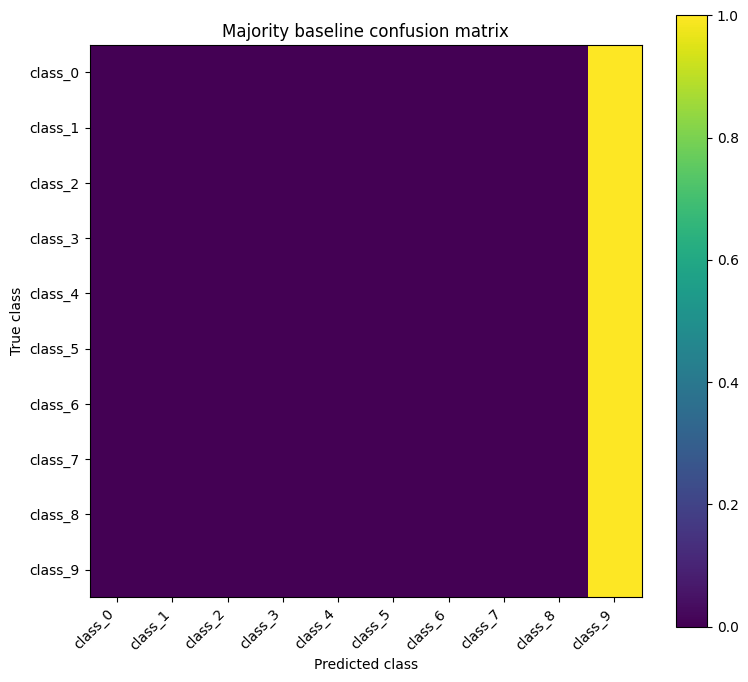

In [16]:
def evaluate_majority_baseline(paths: List[Path],
                               majority_class: int,
                               num_classes: int = NUM_CLASSES) -> Tuple[Dict, pd.DataFrame, np.ndarray]:
    metrics = SegmentationMetrics(num_classes)

    for path in tqdm(paths, desc="Majority baseline"):
        _, labels, _ = read_ply_ascii(path)
        pred_logits = torch.zeros(1, num_classes, len(labels))
        pred_logits[:, majority_class, :] = 1.0
        target = torch.from_numpy(labels).long().unsqueeze(0)
        metrics.update(pred_logits, target)

    return metrics.compute()

majority_class = int(train_class_counts.argmax())
baseline_summary, baseline_per_class, baseline_cm = evaluate_majority_baseline(test_paths, majority_class)

print("Most frequent class in train:", majority_class)
print_metrics(baseline_summary, baseline_per_class)
plot_confusion_matrix(baseline_cm, CLASS_NAMES, title="Majority baseline confusion matrix")

## 12. Модель 1: PointNet для semantic segmentation

PointNet обрабатывает каждую точку MLP-блоком, затем добавляет глобальный признак объекта через max-pooling и выдает класс для каждой точки.

In [17]:
class ConvBNReLU1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class PointNetSeg(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES, input_channels: int = 3):
        super().__init__()

        self.local_mlp = nn.Sequential(
            ConvBNReLU1d(input_channels, 64),
            ConvBNReLU1d(64, 64),
            ConvBNReLU1d(64, 64),
        )

        self.global_mlp = nn.Sequential(
            ConvBNReLU1d(64, 128),
            ConvBNReLU1d(128, 1024),
        )

        self.seg_head = nn.Sequential(
            ConvBNReLU1d(64 + 1024, 512),
            nn.Dropout(p=0.3),
            ConvBNReLU1d(512, 256),
            nn.Dropout(p=0.3),
            ConvBNReLU1d(256, 128),
            nn.Conv1d(128, num_classes, kernel_size=1),
        )

    def forward(self, x):
        """
        x: [B, 3, N]
        returns logits: [B, num_classes, N]
        """
        local_feat = self.local_mlp(x)                       # [B, 64, N]
        global_feat = self.global_mlp(local_feat)            # [B, 1024, N]
        global_feat = torch.max(global_feat, dim=2, keepdim=True)[0]  # [B, 1024, 1]
        global_feat = global_feat.repeat(1, 1, x.shape[2])   # [B, 1024, N]

        feat = torch.cat([local_feat, global_feat], dim=1)   # [B, 1088, N]
        logits = self.seg_head(feat)                         # [B, C, N]
        return logits

## 13. Модель 2: DGCNN / EdgeConv

DGCNN строит локальный граф соседей и применяет EdgeConv. Это обычно лучше ловит локальную геометрию, но требует больше памяти.

In [18]:
def knn(x: torch.Tensor, k: int) -> torch.Tensor:
    """
    x: [B, C, N]
    returns idx: [B, N, k]
    """
    # pairwise distance через матричное умножение
    inner = -2 * torch.matmul(x.transpose(2, 1), x)      # [B, N, N]
    xx = torch.sum(x ** 2, dim=1, keepdim=True)          # [B, 1, N]
    pairwise_distance = -xx.transpose(2, 1) - inner - xx # чем больше, тем ближе
    idx = pairwise_distance.topk(k=k, dim=-1)[1]
    return idx


def get_graph_feature(x: torch.Tensor, k: int = 20, idx: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    x: [B, C, N]
    output: [B, 2C, N, k], где признаки ребра = [neighbor - center, center]
    """
    batch_size, num_dims, num_points = x.size()

    if idx is None:
        idx = knn(x, k=k)

    device = x.device

    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1) * num_points
    idx = idx + idx_base
    idx = idx.view(-1)

    x_t = x.transpose(2, 1).contiguous()                 # [B, N, C]
    feature = x_t.view(batch_size * num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims)

    x_center = x_t.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)
    feature = torch.cat((feature - x_center, x_center), dim=3)
    feature = feature.permute(0, 3, 1, 2).contiguous()    # [B, 2C, N, k]
    return feature


class DGCNNSeg(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES, k: int = 20):
        super().__init__()
        self.k = k

        self.conv1 = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
        )

        self.conv_global = nn.Sequential(
            nn.Conv1d(64 * 3, 1024, kernel_size=1, bias=False),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
        )

        self.seg_head = nn.Sequential(
            nn.Conv1d(1024 + 64 * 3, 512, kernel_size=1, bias=False),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Dropout(p=0.3),

            nn.Conv1d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Dropout(p=0.3),

            nn.Conv1d(256, num_classes, kernel_size=1),
        )

    def forward(self, x):
        """
        x: [B, 3, N]
        returns logits: [B, num_classes, N]
        """
        batch_size, _, num_points = x.size()

        x1 = get_graph_feature(x, k=self.k)
        x1 = self.conv1(x1)
        x1 = x1.max(dim=-1)[0]       # [B, 64, N]

        x2 = get_graph_feature(x1, k=self.k)
        x2 = self.conv2(x2)
        x2 = x2.max(dim=-1)[0]       # [B, 64, N]

        x3 = get_graph_feature(x2, k=self.k)
        x3 = self.conv3(x3)
        x3 = x3.max(dim=-1)[0]       # [B, 64, N]

        local = torch.cat((x1, x2, x3), dim=1)  # [B, 192, N]

        global_feat = self.conv_global(local)   # [B, 1024, N]
        global_feat = torch.max(global_feat, dim=2, keepdim=True)[0]
        global_feat = global_feat.repeat(1, 1, num_points)

        feat = torch.cat((local, global_feat), dim=1)
        logits = self.seg_head(feat)
        return logits

## 14. Обучение и оценка моделей

In [19]:
def build_model(name: str) -> nn.Module:
    name = name.lower()
    if name == "pointnet":
        return PointNetSeg(num_classes=NUM_CLASSES)
    if name == "dgcnn":
        k = MODEL_SETTINGS["dgcnn"].get("k", 20)
        return DGCNNSeg(num_classes=NUM_CLASSES, k=k)
    raise ValueError(f"Unknown model: {name}")


def run_epoch(model: nn.Module,
              loader: DataLoader,
              criterion: nn.Module,
              optimizer: Optional[torch.optim.Optimizer] = None) -> Tuple[float, Dict, pd.DataFrame, np.ndarray]:
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_points = 0
    metrics = SegmentationMetrics(NUM_CLASSES)

    for points, target in tqdm(loader, leave=False):
        points = points.to(DEVICE, non_blocking=True)     # [B, 3, N]
        target = target.to(DEVICE, non_blocking=True)     # [B, N]

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(points)                            # [B, C, N]
        loss = criterion(logits, target)

        if is_train:
            loss.backward()
            optimizer.step()

        batch_points = target.numel()
        total_loss += float(loss.detach().cpu()) * batch_points
        total_points += batch_points

        metrics.update(logits, target)

    avg_loss = total_loss / max(total_points, 1)
    summary, per_class_df, cm = metrics.compute()
    return avg_loss, summary, per_class_df, cm


def train_model(model_name: str,
                epochs: int = EPOCHS,
                lr: float = LR,
                weight_decay: float = WEIGHT_DECAY) -> Tuple[nn.Module, pd.DataFrame, Dict]:
    settings = MODEL_SETTINGS[model_name]
    n_points = settings["n_points"]
    batch_size = settings["batch_size"]

    train_loader, val_loader, test_loader = make_loaders(n_points=n_points, batch_size=batch_size)

    model = build_model(model_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))

    best_miou = -1.0
    best_state = None
    best_epoch = -1
    bad_epochs = 0
    history = []

    print(f"\n===== Training {model_name} | n_points={n_points} | batch_size={batch_size} =====")

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss, train_summary, _, _ = run_epoch(
            model, train_loader, criterion, optimizer=optimizer
        )
        val_loss, val_summary, val_per_class, val_cm = run_epoch(
            model, val_loader, criterion, optimizer=None
        )

        scheduler.step()

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_oa": train_summary["overall_accuracy"],
            "train_miou": train_summary["miou"],
            "train_macro_f1": train_summary["macro_f1"],
            "val_loss": val_loss,
            "val_oa": val_summary["overall_accuracy"],
            "val_miou": val_summary["miou"],
            "val_macro_f1": val_summary["macro_f1"],
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": time.time() - start,
        }
        history.append(row)

        print(
            f"epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} miou {train_summary['miou']:.4f} | "
            f"val loss {val_loss:.4f} miou {val_summary['miou']:.4f} "
            f"oa {val_summary['overall_accuracy']:.4f} f1 {val_summary['macro_f1']:.4f}"
        )

        if val_summary["miou"] > best_miou:
            best_miou = val_summary["miou"]
            best_epoch = epoch
            bad_epochs = 0
            best_state = copy.deepcopy(model.state_dict())

            ckpt_path = OUTPUT_DIR / f"{model_name}_best.pt"
            torch.save({
                "model_name": model_name,
                "state_dict": best_state,
                "epoch": epoch,
                "best_val_miou": best_miou,
                "settings": settings,
            }, ckpt_path)
        else:
            bad_epochs += 1

        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping: нет улучшения {EARLY_STOPPING_PATIENCE} эпох.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    test_loss, test_summary, test_per_class, test_cm = run_epoch(
        model, test_loader, criterion, optimizer=None
    )

    test_info = {
        "model": model_name,
        "best_epoch": best_epoch,
        "best_val_miou": best_miou,
        "test_loss": test_loss,
        **{f"test_{k}": v for k, v in test_summary.items()},
        "test_per_class": test_per_class,
        "test_cm": test_cm,
    }

    test_per_class.to_csv(OUTPUT_DIR / f"{model_name}_test_per_class_metrics.csv", index=False)
    pd.DataFrame(test_cm).to_csv(OUTPUT_DIR / f"{model_name}_test_confusion_matrix.csv", index=False)

    return model, history_df, test_info

## 15. Запуск обучения

In [20]:
trained_models = {}
histories = {}
test_infos = []

for model_name in MODELS_TO_TRAIN:
    model, history_df, test_info = train_model(model_name)
    trained_models[model_name] = model
    histories[model_name] = history_df
    test_infos.append(test_info)

print("Готово.")


===== Training pointnet | n_points=4096 | batch_size=2 =====


  0%|          | 0/175 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

epoch 001 | train loss 1.5173 miou 0.2075 | val loss 1.4446 miou 0.1851 oa 0.5131 f1 0.2716


  0%|          | 0/175 [00:00<?, ?it/s]

...

  0%|          | 0/175 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

epoch 030 | train loss 0.2828 miou 0.6956 | val loss 0.2314 miou 0.7499 oa 0.9289 f1 0.8425


  0%|          | 0/38 [00:00<?, ?it/s]

Готово.


## 16. Таблица сравнения моделей

In [21]:
results_rows = []

results_rows.append({
    "model": "majority_baseline",
    "best_epoch": None,
    "best_val_miou": None,
    "test_loss": None,
    "test_overall_accuracy": baseline_summary["overall_accuracy"],
    "test_miou": baseline_summary["miou"],
    "test_macro_f1": baseline_summary["macro_f1"],
    "test_weighted_f1": baseline_summary["weighted_f1"],
})

for info in test_infos:
    results_rows.append({
        "model": info["model"],
        "best_epoch": info["best_epoch"],
        "best_val_miou": info["best_val_miou"],
        "test_loss": info["test_loss"],
        "test_overall_accuracy": info["test_overall_accuracy"],
        "test_miou": info["test_miou"],
        "test_macro_f1": info["test_macro_f1"],
        "test_weighted_f1": info["test_weighted_f1"],
    })

results_df = pd.DataFrame(results_rows)
display(results_df)

results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
print("Сохранено:", OUTPUT_DIR / "model_comparison.csv")

,model,best_epoch,best_val_miou,test_loss,test_overall_accuracy,test_miou,test_macro_f1,test_weighted_f1
0,majority_baseline,NaN,NaN,NaN,0.378868,0.037887,0.054953,0.208201
1,pointnet,25.0,0.761525,0.214256,0.925605,0.763119,0.854572,0.925852


Сохранено: outputs_valve_segmentation/model_comparison.csv


## 17. Графики обучения

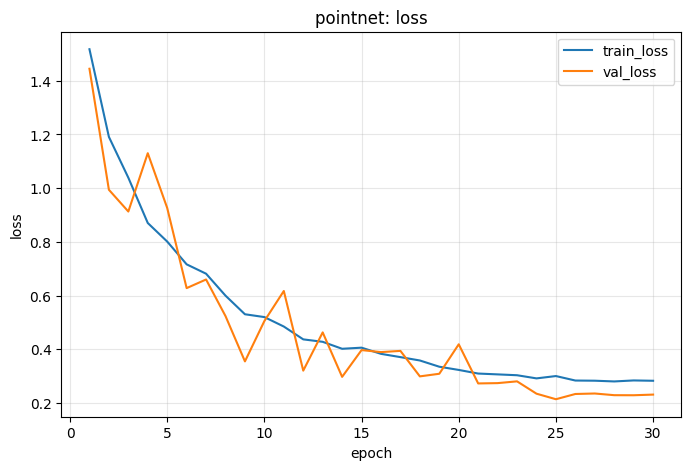

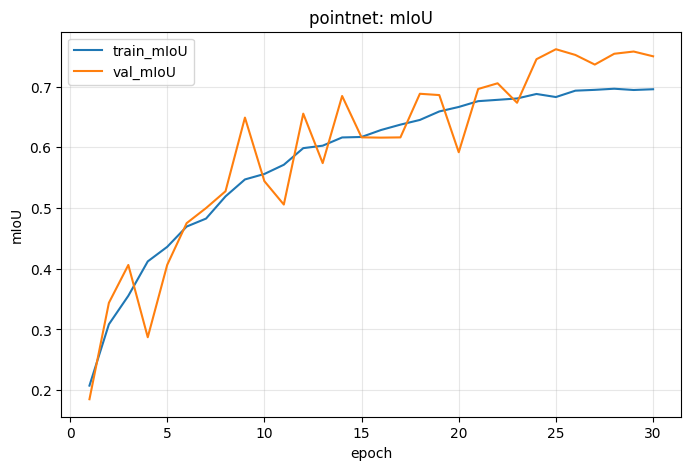

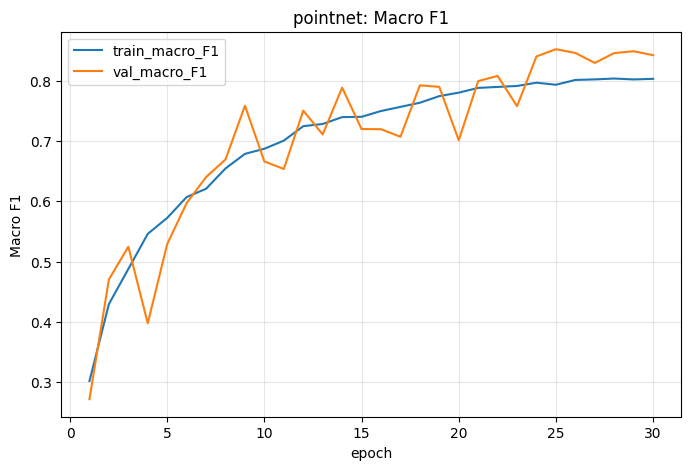

In [22]:
def plot_history(history_df: pd.DataFrame, model_name: str):
    if history_df.empty:
        print(f"{model_name}: empty history")
        return

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.title(f"{model_name}: loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_miou"], label="train_mIoU")
    plt.plot(history_df["epoch"], history_df["val_miou"], label="val_mIoU")
    plt.title(f"{model_name}: mIoU")
    plt.xlabel("epoch")
    plt.ylabel("mIoU")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_F1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_F1")
    plt.title(f"{model_name}: Macro F1")
    plt.xlabel("epoch")
    plt.ylabel("Macro F1")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

for model_name, history_df in histories.items():
    plot_history(history_df, model_name)

## 18. Confusion Matrix и метрики по классам

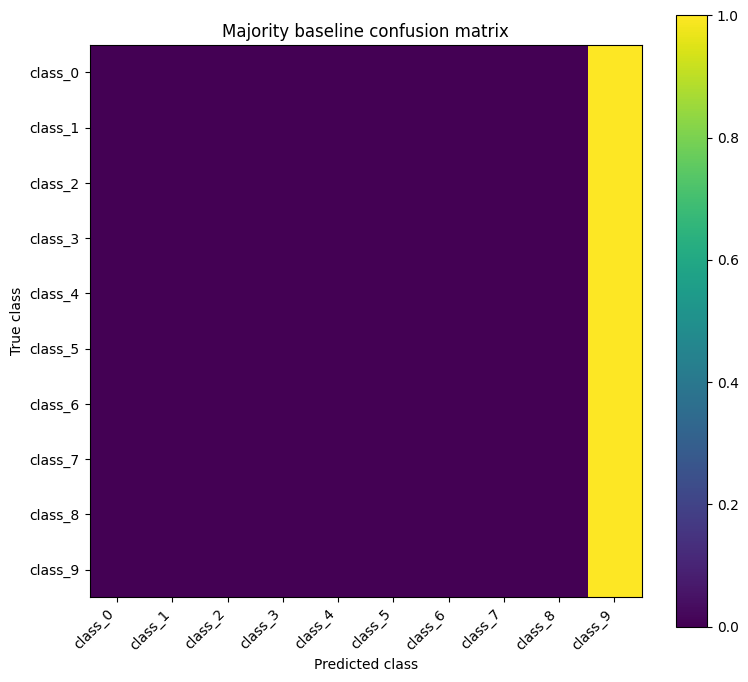


MODEL: pointnet


,class_id,class_name,support,pred_count,precision,recall,f1,iou
0,0,class_0,50796,45253,0.945705,0.842507,0.891128,0.803635
1,1,class_1,35260,36994,0.887928,0.931594,0.909237,0.833579
2,2,class_2,18255,17332,0.962382,0.913722,0.937421,0.882213
3,3,class_3,24424,28667,0.816304,0.958115,0.881543,0.788178
4,4,class_4,2391,2693,0.564055,0.635299,0.597561,0.426087
5,5,class_5,3747,4128,0.746609,0.822525,0.782730,0.643021
6,6,class_6,27765,26906,0.946778,0.917486,0.931902,0.872487
7,7,class_7,26029,26479,0.960233,0.976834,0.968462,0.938852
8,8,class_8,1807,1747,0.700057,0.676812,0.688239,0.524668
9,9,class_9,116726,117001,0.956376,0.958630,0.957502,0.918468


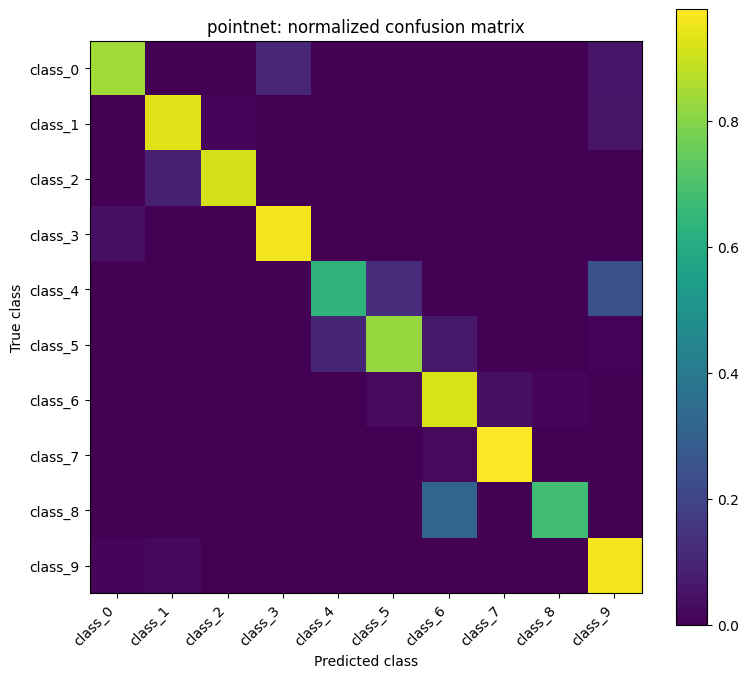

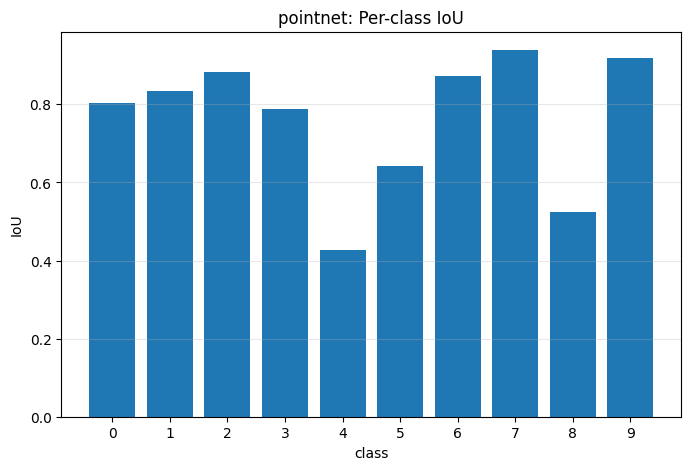

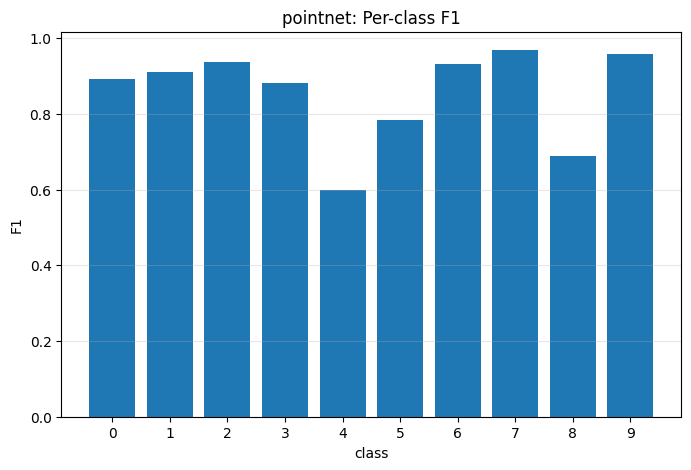

In [23]:
# Baseline confusion matrix
plot_confusion_matrix(
    baseline_cm,
    CLASS_NAMES,
    title="Majority baseline confusion matrix",
    normalize=True,
)

for info in test_infos:
    model_name = info["model"]
    print("\n", "=" * 80)
    print("MODEL:", model_name)

    per_class_df = info["test_per_class"]
    cm = info["test_cm"]

    display(per_class_df)

    plot_confusion_matrix(
        cm,
        CLASS_NAMES,
        title=f"{model_name}: normalized confusion matrix",
        normalize=True,
    )

    plt.figure(figsize=(8, 5))
    plt.bar(per_class_df["class_id"], per_class_df["iou"])
    plt.title(f"{model_name}: Per-class IoU")
    plt.xlabel("class")
    plt.ylabel("IoU")
    plt.xticks(per_class_df["class_id"])
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(per_class_df["class_id"], per_class_df["f1"])
    plt.title(f"{model_name}: Per-class F1")
    plt.xlabel("class")
    plt.ylabel("F1")
    plt.xticks(per_class_df["class_id"])
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

## 19. Предсказание и визуализация результата на одном объекте

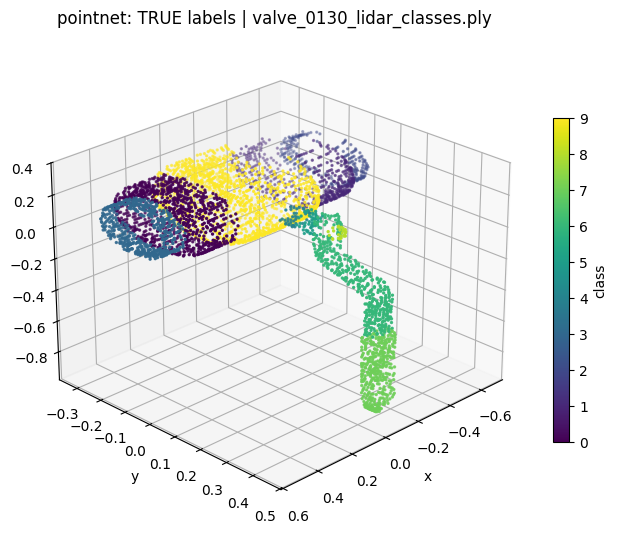

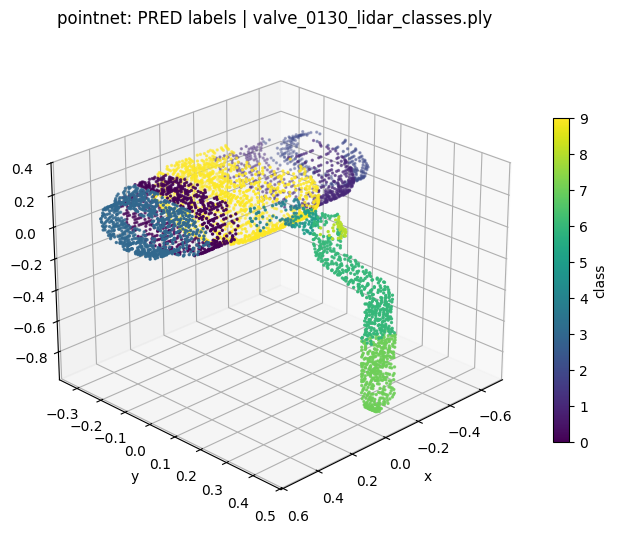

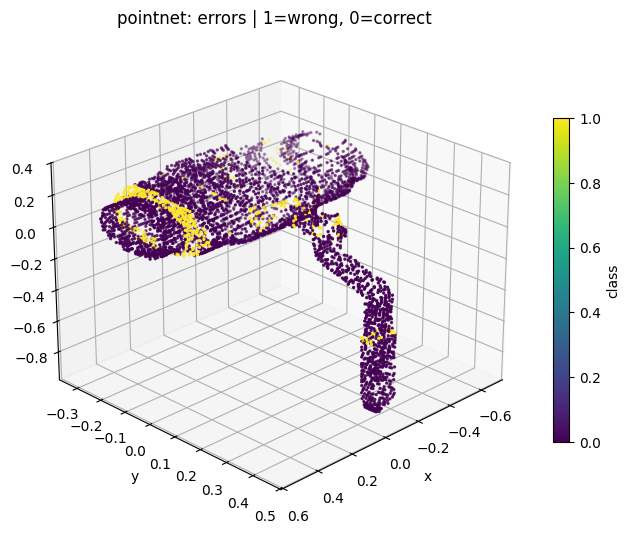

In [24]:
@torch.no_grad()
def predict_cloud(model: nn.Module,
                  path: Path,
                  max_points: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Делает предсказание для одного .ply.
    Если max_points задан и объект больше, предсказывает на случайной подвыборке.
    """
    model.eval()

    coords_raw, labels, _ = read_ply_ascii(path)
    coords = normalize_coords(coords_raw)

    if max_points is not None and len(coords) > max_points:
        idx = np.random.choice(len(coords), max_points, replace=False)
        coords_eval = coords[idx]
        labels_eval = labels[idx]
    else:
        coords_eval = coords
        labels_eval = labels

    x = torch.from_numpy(coords_eval.T).float().unsqueeze(0).to(DEVICE)  # [1, 3, N]
    logits = model(x)
    pred = logits.argmax(dim=1).squeeze(0).detach().cpu().numpy()

    return coords_eval, labels_eval, pred


if len(trained_models) > 0:
    model_name = list(trained_models.keys())[0]
    model = trained_models[model_name]

    path = test_paths[0]
    coords_eval, true_labels, pred_labels = predict_cloud(
        model,
        path,
        max_points=4096,
    )

    visualize_cloud(coords_eval, true_labels, title=f"{model_name}: TRUE labels | {path.name}")
    visualize_cloud(coords_eval, pred_labels, title=f"{model_name}: PRED labels | {path.name}")

    errors = (true_labels != pred_labels).astype(int)
    visualize_cloud(coords_eval, errors, title=f"{model_name}: errors | 1=wrong, 0=correct")
else:
    print("Сначала обучите хотя бы одну модель.")